# CCKS2021 中文NLP地址相关性 — 特征工程

本 notebook 完成以下工作：
1. 数据加载与探索（标签分布、文本长度等）
2. 数据预处理与清洗（分词、标准化）
3. 基础统计特征（长度、数字占比、Jaccard相似度等）
4. 语义特征（预训练BERT编码相似度）
5. 地址要素对齐特征
6. 特征保存，供下游模型训练使用

In [22]:
# ============ 1. 导入依赖 ============
import json
import re
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
import Levenshtein

# 可视化
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# NLP工具
import jieba
import jieba.posseg as pseg

# 机器学习
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# PyTorch & Transformers
import torch
from transformers import AutoTokenizer, AutoModel

print("所有依赖导入成功！")
print(f"PyTorch版本: {torch.__version__}")
print(f"CUDA可用: {torch.cuda.is_available()}")

所有依赖导入成功！
PyTorch版本: 2.12.0+cpu
CUDA可用: False


In [23]:
# ============ 2. 数据加载 ============
# 获取项目根目录（notebook在 script/ 下，上级是项目根目录）
import sys
# 如果当前在项目根目录，往上找script
if os.path.basename(os.getcwd()) == 'script':
    PROJECT_DIR = os.path.dirname(os.getcwd())
elif os.path.basename(os.getcwd()) == '期末作业':
    PROJECT_DIR = os.getcwd()
else:
    PROJECT_DIR = os.getcwd()

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
OUTPUT_DIR = os.path.join(PROJECT_DIR, 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"项目目录: {PROJECT_DIR}")
print(f"数据目录: {DATA_DIR}")
print(f"输出目录: {OUTPUT_DIR}")

def load_jsonl(filename):
    """加载JSONL格式数据"""
    data = []
    filepath = os.path.join(DATA_DIR, filename)
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                data.append(json.loads(line))
    return pd.DataFrame(data)

# 加载全部数据
train_df = load_jsonl('train.json')
dev_df = load_jsonl('dev.json')

print(f"训练集: {train_df.shape}")
print(f"验证集: {dev_df.shape}")
print("\n训练集前5行:")
display(train_df.head())

项目目录: e:\1学习文件\数据可视化\期末作业
数据目录: e:\1学习文件\数据可视化\期末作业\data
输出目录: e:\1学习文件\数据可视化\期末作业\output
训练集: (96423, 3)
验证集: (22974, 3)

训练集前5行:


,sentence1,sentence2,label
0,思明区中华街道大同路思东商厦3梯,霞溪路187号霞溪路181-187思东商厦-四梯,partial_match
1,杭州市清源村合联2组,临安区联合村,not_match
2,北京市牛王庙村4号岗,朝阳区牛王庙4号楼,partial_match
3,苏家屯区月季街9号楼,苏家屯区萃华园9号楼,not_match
4,江苏省南京市秦淮区洪武路街道北门桥路1洪武路168号一单元,太平南路四象桥西一巷,not_match


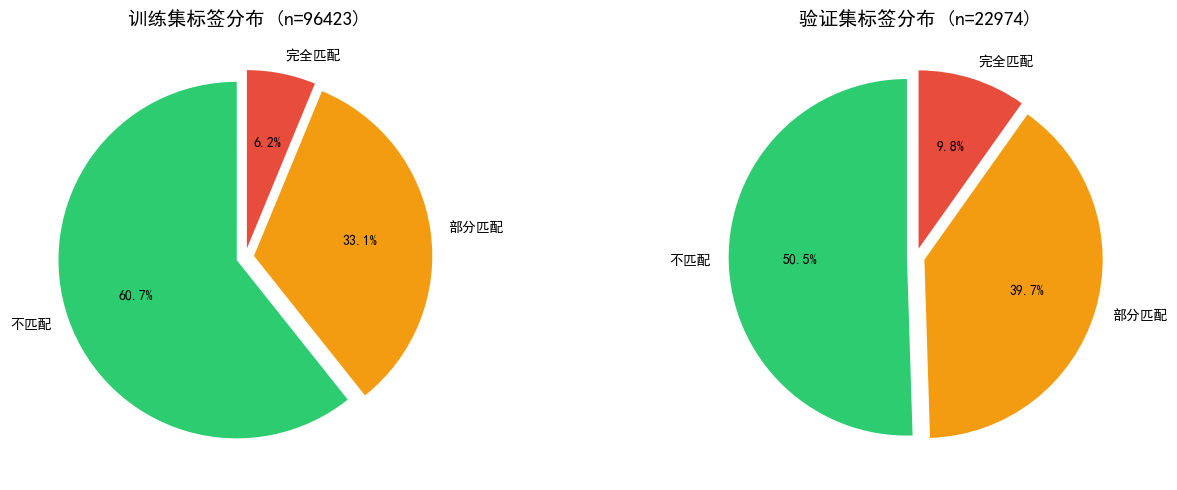


训练集标签计数:
label
not_match        58525
partial_match    31891
exact_match       6007
Name: count, dtype: int64

验证集标签计数:
label
not_match        11603
partial_match     9114
exact_match       2257
Name: count, dtype: int64


In [24]:
# ============ 3. 标签分布 ============
label_map = {'exact_match': '完全匹配', 'partial_match': '部分匹配', 'not_match': '不匹配'}
train_df['label_zh'] = train_df['label'].map(label_map)
dev_df['label_zh'] = dev_df['label'].map(label_map)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 训练集标签分布
train_counts = train_df['label_zh'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].pie(train_counts.values, labels=train_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
axes[0].set_title(f'训练集标签分布 (n={len(train_df)})', fontsize=14)

# 验证集标签分布
dev_counts = dev_df['label_zh'].value_counts()
axes[1].pie(dev_counts.values, labels=dev_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1].set_title(f'验证集标签分布 (n={len(dev_df)})', fontsize=14)

plt.tight_layout()
plt.show()

print("\n训练集标签计数:")
print(train_df['label'].value_counts())
print("\n验证集标签计数:")
print(dev_df['label'].value_counts())

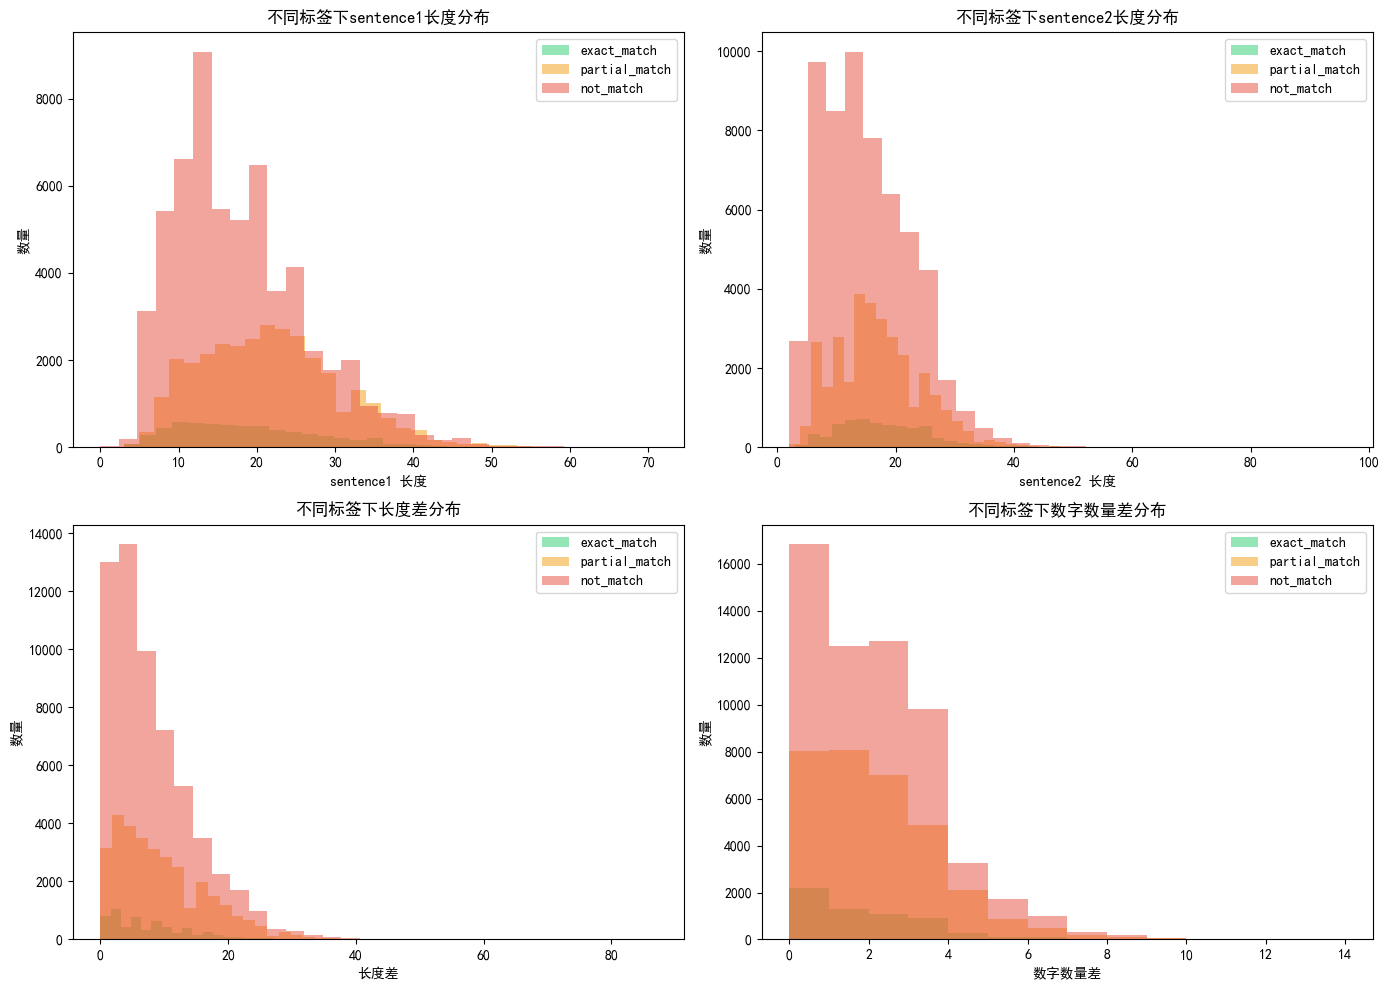

In [25]:
# ============ 4. 文本长度与基础统计 ============
def calc_basic_stats(df):
    """计算地址文本基础统计特征"""
    stats = pd.DataFrame(index=df.index)
    
    # sentence1 (query) 长度特征
    stats['s1_len'] = df['sentence1'].apply(len)
    stats['s2_len'] = df['sentence2'].apply(len)
    stats['len_diff'] = abs(stats['s1_len'] - stats['s2_len'])
    stats['len_ratio'] = stats['s1_len'] / (stats['s2_len'] + 1)
    
    # 数字数量
    stats['s1_num_count'] = df['sentence1'].apply(lambda x: sum(c.isdigit() for c in x))
    stats['s2_num_count'] = df['sentence2'].apply(lambda x: sum(c.isdigit() for c in x))
    stats['num_diff'] = abs(stats['s1_num_count'] - stats['s2_num_count'])
    
    # 数字占比
    stats['s1_num_ratio'] = stats['s1_num_count'] / (stats['s1_len'] + 1)
    stats['s2_num_ratio'] = stats['s2_num_count'] / (stats['s2_len'] + 1)
    
    # 中文字符数
    stats['s1_chinese_count'] = df['sentence1'].apply(lambda x: sum(1 for c in x if '\u4e00' <= c <= '\u9fff'))
    stats['s2_chinese_count'] = df['sentence2'].apply(lambda x: sum(1 for c in x if '\u4e00' <= c <= '\u9fff'))
    stats['s1_chinese_ratio'] = stats['s1_chinese_count'] / (stats['s1_len'] + 1)
    stats['s2_chinese_ratio'] = stats['s2_chinese_count'] / (stats['s2_len'] + 1)
    
    return stats

train_stats = calc_basic_stats(train_df)

# 可视化长度分布
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors_map = {'exact_match': '#2ecc71', 'partial_match': '#f39c12', 'not_match': '#e74c3c'}

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[0, 0].hist(train_stats.loc[mask, 's1_len'], alpha=0.5, label=label, color=colors_map[label], bins=30)
    
axes[0, 0].set_xlabel('sentence1 长度')
axes[0, 0].set_ylabel('数量')
axes[0, 0].set_title('不同标签下sentence1长度分布')
axes[0, 0].legend()

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[0, 1].hist(train_stats.loc[mask, 's2_len'], alpha=0.5, label=label, color=colors_map[label], bins=30)
    
axes[0, 1].set_xlabel('sentence2 长度')
axes[0, 1].set_ylabel('数量')
axes[0, 1].set_title('不同标签下sentence2长度分布')
axes[0, 1].legend()

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[1, 0].hist(train_stats.loc[mask, 'len_diff'], alpha=0.5, label=label, color=colors_map[label], bins=30)
    
axes[1, 0].set_xlabel('长度差')
axes[1, 0].set_ylabel('数量')
axes[1, 0].set_title('不同标签下长度差分布')
axes[1, 0].legend()

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[1, 1].hist(train_stats.loc[mask, 'num_diff'], alpha=0.5, label=label, color=colors_map[label], bins=range(0, 15))
    
axes[1, 1].set_xlabel('数字数量差')
axes[1, 1].set_ylabel('数量')
axes[1, 1].set_title('不同标签下数字数量差分布')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

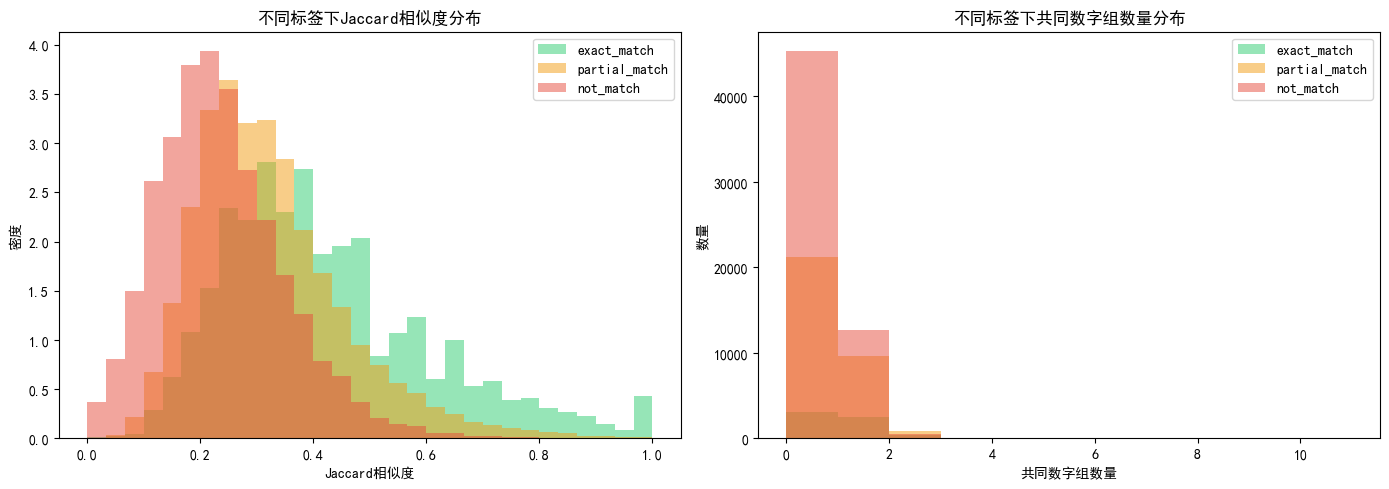

In [26]:
# ============ 5. Jaccard相似度与共现特征 ============
def jaccard_similarity(s1, s2):
    """计算Jaccard相似度（基于字符集合）"""
    set1, set2 = set(s1), set(s2)
    intersection = set1 & set2
    union = set1 | set2
    return len(intersection) / (len(union) + 1e-8)

def char_overlap_ratio(s1, s2):
    """计算字符重叠比例"""
    set1, set2 = set(s1), set(s2)
    intersection = set1 & set2
    return len(intersection) / (len(set1) + 1e-8)

def calc_similarity_features(df):
    """计算相似度特征"""
    features = pd.DataFrame(index=df.index)
    
    # Jaccard相似度
    features['jaccard_sim'] = df.apply(lambda x: jaccard_similarity(x['sentence1'], x['sentence2']), axis=1)
    
    # 字符重叠比例 (相对于sentence1)
    features['overlap_ratio_s1'] = df.apply(lambda x: char_overlap_ratio(x['sentence1'], x['sentence2']), axis=1)
    features['overlap_ratio_s2'] = df.apply(lambda x: char_overlap_ratio(x['sentence2'], x['sentence1']), axis=1)
    
    # 共同字符数
    features['common_chars'] = df.apply(
        lambda x: len(set(x['sentence1']) & set(x['sentence2'])), axis=1)
    
    # 数字重叠
    def get_digits(s):
        return set(re.findall(r'\d+', s))
    
    features['common_digits'] = df.apply(
        lambda x: len(get_digits(x['sentence1']) & get_digits(x['sentence2'])), axis=1)
    
    return features

train_sim_features = calc_similarity_features(train_df)

# 可视化Jaccard相似度分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[0].hist(train_sim_features.loc[mask, 'jaccard_sim'], alpha=0.5, 
                 label=label, color=colors_map[label], bins=30, density=True)
axes[0].set_xlabel('Jaccard相似度')
axes[0].set_ylabel('密度')
axes[0].set_title('不同标签下Jaccard相似度分布')
axes[0].legend()

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[1].hist(train_sim_features.loc[mask, 'common_digits'], alpha=0.5, 
                 label=label, color=colors_map[label], bins=range(0, 12))
axes[1].set_xlabel('共同数字组数量')
axes[1].set_ylabel('数量')
axes[1].set_title('不同标签下共同数字组数量分布')
axes[1].legend()

plt.tight_layout()
plt.show()

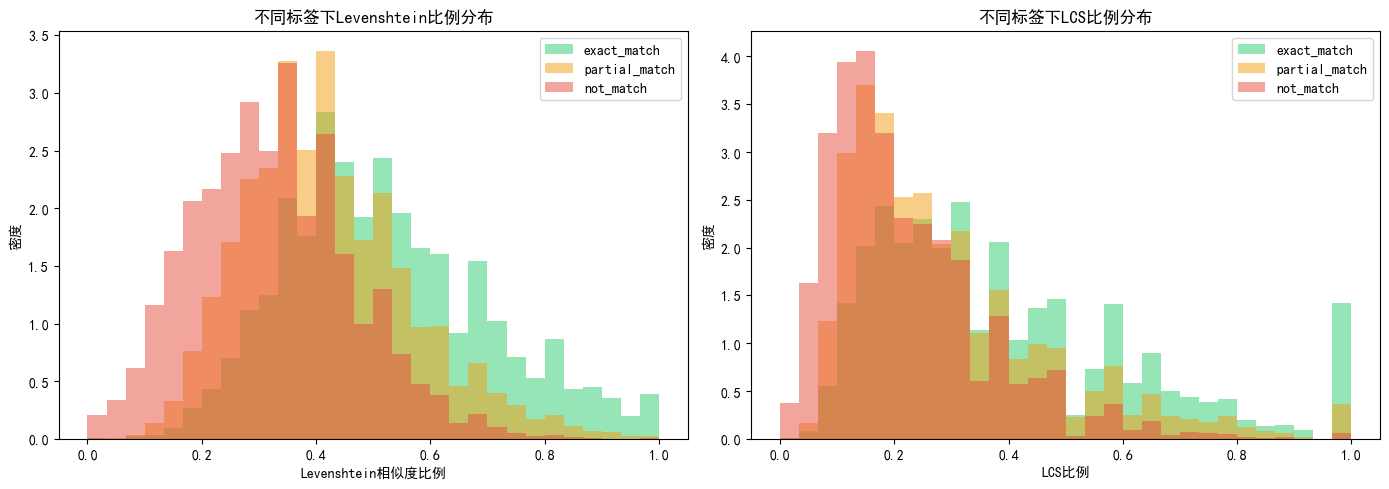

In [27]:
# ============ 6. 编辑距离特征 ============
def calc_edit_distance_features(df):
    """计算编辑距离类特征"""
    features = pd.DataFrame(index=df.index)
    
    # Levenshtein距离
    features['levenshtein_dist'] = df.apply(
        lambda x: Levenshtein.distance(x['sentence1'], x['sentence2']), axis=1)
    features['levenshtein_ratio'] = df.apply(
        lambda x: Levenshtein.ratio(x['sentence1'], x['sentence2']), axis=1)
    
    # 归一化编辑距离
    features['norm_edit_dist'] = features['levenshtein_dist'] / \
        (df['sentence1'].str.len() + df['sentence2'].str.len() + 1)
    
    # 最长公共子串长度
    def longest_common_substr(s1, s2):
        m, n = len(s1), len(s2)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        max_len = 0
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if s1[i-1] == s2[j-1]:
                    dp[i][j] = dp[i-1][j-1] + 1
                    max_len = max(max_len, dp[i][j])
        return max_len
    
    features['lcs_len'] = df.apply(
        lambda x: longest_common_substr(x['sentence1'], x['sentence2']), axis=1)
    features['lcs_ratio'] = features['lcs_len'] / \
        (df['sentence1'].str.len() + 1e-8)
    
    return features

train_edit_features = calc_edit_distance_features(train_df)

# 可视化编辑距离特征
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[0].hist(train_edit_features.loc[mask, 'levenshtein_ratio'], alpha=0.5, 
                 label=label, color=colors_map[label], bins=30, density=True)
axes[0].set_xlabel('Levenshtein相似度比例')
axes[0].set_ylabel('密度')
axes[0].set_title('不同标签下Levenshtein比例分布')
axes[0].legend()

for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    axes[1].hist(train_edit_features.loc[mask, 'lcs_ratio'], alpha=0.5, 
                 label=label, color=colors_map[label], bins=30, density=True)
axes[1].set_xlabel('LCS比例')
axes[1].set_ylabel('密度')
axes[1].set_title('不同标签下LCS比例分布')
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
# ============ 7. 地址要素分词与关键成分提取 ============
# 加载自定义地址词典
jieba.load_userdict(os.path.join(os.path.dirname(os.getcwd()), 'data', 'address_dict.txt')) if os.path.exists(
    os.path.join(os.path.dirname(os.getcwd()), 'data', 'address_dict.txt')) else None

# 地址要素关键词
ADDR_KEYWORDS = {
    'province': ['省', '自治区'],
    'city': ['市', '自治州', '地区', '盟'],
    'district': ['区', '县', '县级市', '旗', '自治县'],
    'street': ['街道', '镇', '乡', '路', '街', '大道', '巷', '弄', '条'],
    'village': ['村', '社区', '新村', '屯', '组'],
    'building': ['栋', '号楼', '楼', '单元', '室', '号院', '大厦', '广场', '中心', '城'],
    'poi': ['店', '公司', '厂', '酒店', '宾馆', '超市', '市场', '银行', '医院', '学校', '园', '馆'],
}

def extract_addr_components(text):
    """提取地址要素"""
    components = {}
    words = pseg.lcut(text)
    
    for word, flag in words:
        for comp_type, keywords in ADDR_KEYWORDS.items():
            if any(kw in word for kw in keywords):
                if comp_type not in components:
                    components[comp_type] = []
                components[comp_type].append(word)
    
    return components

def calc_addr_component_features(df):
    """计算地址要素匹配特征"""
    features = pd.DataFrame(index=df.index)
    
    features['s1_component_cnt'] = 0
    features['s2_component_cnt'] = 0
    features['component_overlap'] = 0
    
    for i in tqdm(range(len(df)), desc="提取地址要素"):
        comp1 = extract_addr_components(df.iloc[i]['sentence1'])
        comp2 = extract_addr_components(df.iloc[i]['sentence2'])
        
        features.loc[i, 's1_component_cnt'] = sum(len(v) for v in comp1.values())
        features.loc[i, 's2_component_cnt'] = sum(len(v) for v in comp2.values())
        
        # 计算共有要素类型数
        common_types = set(comp1.keys()) & set(comp2.keys())
        features.loc[i, 'component_overlap'] = len(common_types)
    
    return features

# 由于数据量大，这里采样计算（完整计算可在model.py中高效处理）
sample_size = min(5000, len(train_df))
sample_idx = np.random.RandomState(42).choice(len(train_df), sample_size, replace=False)
sample_df = train_df.iloc[sample_idx].copy()
sample_comp_features = calc_addr_component_features(sample_df)

print("地址要素特征示例:")
display(sample_comp_features.describe())

提取地址要素: 100%|██████████| 5000/5000 [00:09<00:00, 542.75it/s]

地址要素特征示例:


,s1_component_cnt,s2_component_cnt,component_overlap
count,9743.000000,9743.000000,9743.000000
mean,2.118855,1.396182,0.762291
std,2.663892,1.689046,0.964440
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,1.000000,0.000000
75%,4.000000,3.000000,1.000000
max,15.000000,12.000000,5.000000


正在加载预训练模型: hfl/chinese-bert-wwm-ext


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 34864.93it/s]
[transformers] BertModel LOAD REPORT from: hfl/chinese-bert-wwm-ext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


模型已加载到CPU

编码5000条地址的BERT向量...


BERT编码: 100%|██████████| 79/79 [01:23<00:00,  1.06s/it]


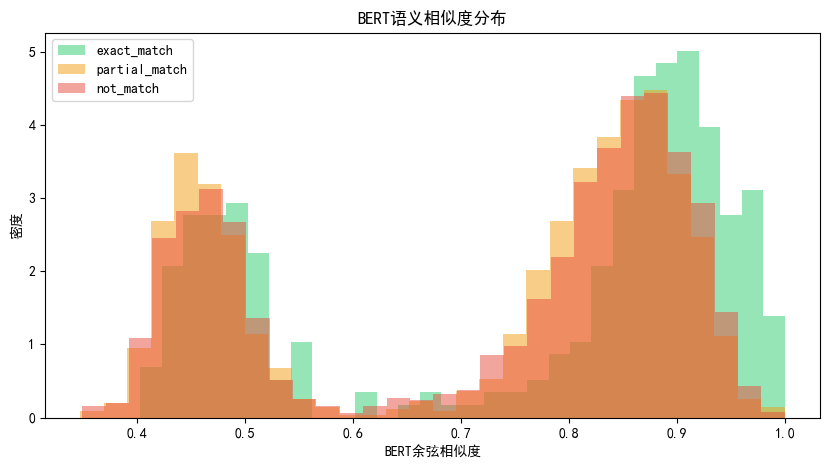


BERT语义相似度统计:
  exact_match: mean=0.7644, std=0.1971
  partial_match: mean=0.7170, std=0.1898
  not_match: mean=0.7242, std=0.1889


In [29]:
# ============ 8. BERT语义向量相似度特征（使用chinese-bert-wwm） ============
# 参考冠军方案使用的预训练模型，这里使用较小的bert-base-chinese进行特征提取
MODEL_NAME = 'hfl/chinese-bert-wwm-ext'

def get_bert_embedding(texts, tokenizer, model, batch_size=32, max_len=128):
    """批量获取BERT句向量"""
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size), desc="BERT编码"):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(batch, padding=True, truncation=True, 
                              max_length=max_len, return_tensors='pt')
            
            # 移到GPU
            if torch.cuda.is_available():
                inputs = {k: v.cuda() for k, v in inputs.items()}
                model = model.cuda()
            
            outputs = model(**inputs)
            # 使用[CLS]向量作为句向量
            cls_emb = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            embeddings.append(cls_emb)
    
    return np.concatenate(embeddings, axis=0)

# 加载模型（如果GPU内存不足，可以只加载到CPU）
print(f"正在加载预训练模型: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModel.from_pretrained(MODEL_NAME)

if torch.cuda.is_available():
    model = model.cuda()
    print("模型已加载到GPU")
else:
    print("模型已加载到CPU")

# 由于数据量大，使用子集演示（完整特征提取将在model.py的预处理中完成）
sample_texts1 = train_df['sentence1'].iloc[:sample_size].tolist()
sample_texts2 = train_df['sentence2'].iloc[:sample_size].tolist()

print(f"\n编码{sample_size}条地址的BERT向量...")
emb1 = get_bert_embedding(sample_texts1, tokenizer, model, batch_size=64)
emb2 = get_bert_embedding(sample_texts2, tokenizer, model, batch_size=64)

# 计算余弦相似度
bert_sim = np.sum(emb1 * emb2, axis=1) / (
    np.linalg.norm(emb1, axis=1) * np.linalg.norm(emb2, axis=1) + 1e-8)

sample_labels = train_df['label'].iloc[:sample_size]

fig, ax = plt.subplots(figsize=(10, 5))
for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = sample_labels.values == label
    ax.hist(bert_sim[mask], alpha=0.5, label=label, color=colors_map[label], bins=30, density=True)
ax.set_xlabel('BERT余弦相似度')
ax.set_ylabel('密度')
ax.set_title('BERT语义相似度分布')
ax.legend()
plt.show()

print(f"\nBERT语义相似度统计:")
for label in ['exact_match', 'partial_match', 'not_match']:
    mask = sample_labels.values == label
    print(f"  {label}: mean={bert_sim[mask].mean():.4f}, std={bert_sim[mask].std():.4f}")

构建训练集特征...
构建基础统计特征...
构建相似度特征...
构建编辑距离特征...
  特征列: ['s1_len', 's2_len', 'len_diff', 'len_ratio', 's1_num_count', 's2_num_count', 'num_diff', 's1_num_ratio', 's2_num_ratio', 's1_chinese_count', 's2_chinese_count', 's1_chinese_ratio', 's2_chinese_ratio', 'jaccard_sim', 'overlap_ratio_s1', 'overlap_ratio_s2', 'common_chars', 'common_digits', 'levenshtein_dist', 'levenshtein_ratio', 'norm_edit_dist', 'lcs_len', 'lcs_ratio']

构建验证集特征...
构建基础统计特征...
构建相似度特征...
构建编辑距离特征...
  特征列: ['s1_len', 's2_len', 'len_diff', 'len_ratio', 's1_num_count', 's2_num_count', 'num_diff', 's1_num_ratio', 's2_num_ratio', 's1_chinese_count', 's2_chinese_count', 's1_chinese_ratio', 's2_chinese_ratio', 'jaccard_sim', 'overlap_ratio_s1', 'overlap_ratio_s2', 'common_chars', 'common_digits', 'levenshtein_dist', 'levenshtein_ratio', 'norm_edit_dist', 'lcs_len', 'lcs_ratio']

训练集特征 shape: (96423, 27)
验证集特征 shape: (22974, 27)

✓ 特征已保存到 e:\1学习文件\数据可视化\期末作业\output/
  - train_features.csv (96423行, 27列)
  - dev_features.csv 

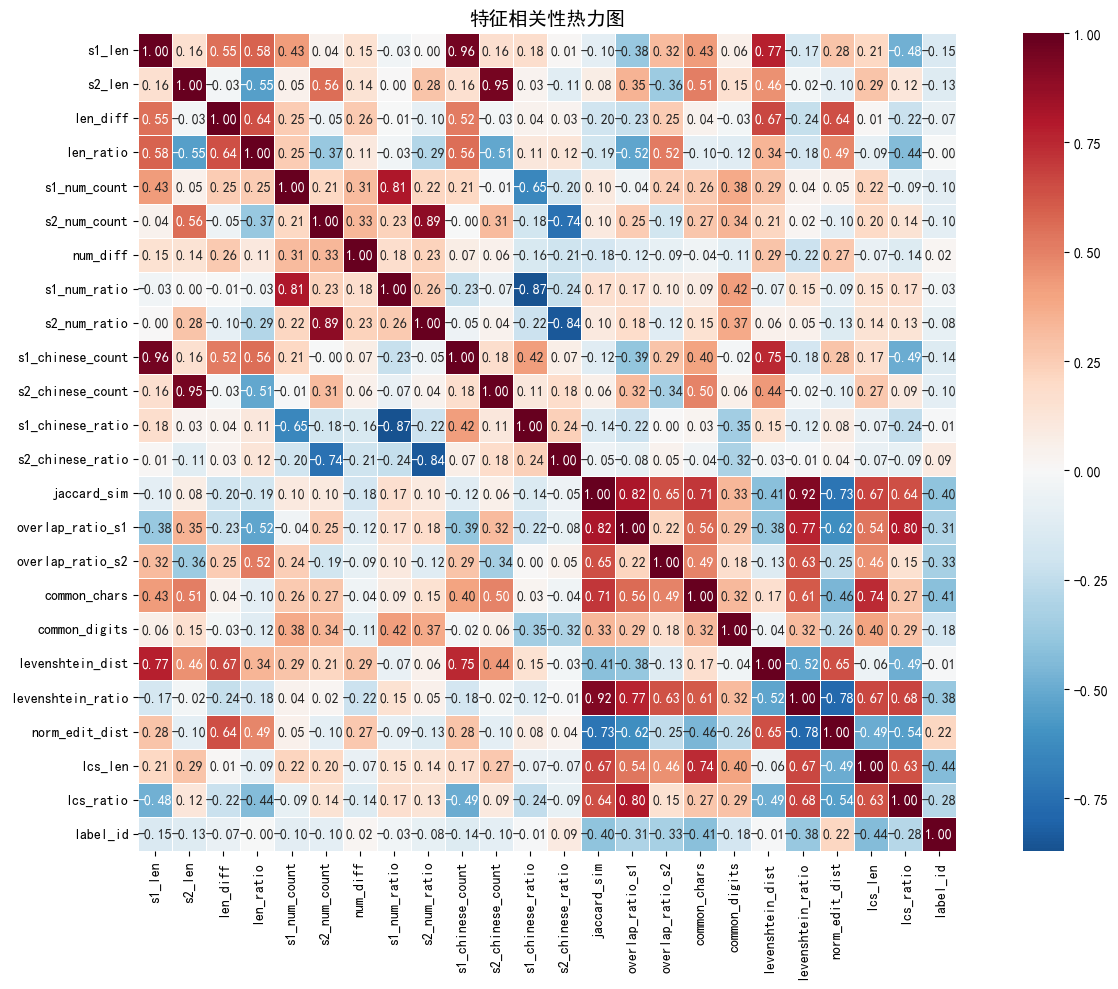

In [30]:
# ============ 9. 特征整合与保存 ============
def build_all_features(df):
    """构建全部特征"""
    print("构建基础统计特征...")
    basic = calc_basic_stats(df)
    
    print("构建相似度特征...")
    sim = calc_similarity_features(df)
    
    print("构建编辑距离特征...")
    edit = calc_edit_distance_features(df)
    
    # 合并所有特征
    all_features = pd.concat([basic, sim, edit], axis=1)
    print(f"  特征列: {list(all_features.columns)}")
    
    # 同时保存原始文本和标签
    all_features['sentence1'] = df['sentence1'].values
    all_features['sentence2'] = df['sentence2'].values
    all_features['label'] = df['label'].values
    all_features['label_id'] = df['label'].map({'exact_match': 0, 'partial_match': 1, 'not_match': 2}).values
    
    return all_features

# 为训练集和验证集构建特征
print("="*50)
print("构建训练集特征...")
train_features = build_all_features(train_df)

print("\n构建验证集特征...")
dev_features = build_all_features(dev_df)

print(f"\n训练集特征 shape: {train_features.shape}")
print(f"验证集特征 shape: {dev_features.shape}")

# 保存到output目录
train_features.to_csv(os.path.join(OUTPUT_DIR, 'train_features.csv'), index=False)
dev_features.to_csv(os.path.join(OUTPUT_DIR, 'dev_features.csv'), index=False)
print(f"\n✓ 特征已保存到 {OUTPUT_DIR}/")
print(f"  - train_features.csv ({len(train_features)}行, {len(train_features.columns)}列)")
print(f"  - dev_features.csv ({len(dev_features)}行, {len(dev_features.columns)}列)")

# 特征相关性热力图
feature_cols = [c for c in train_features.columns 
                if c not in ['label', 'label_id', 'sentence1', 'sentence2']]
corr_matrix = train_features[feature_cols + ['label_id']].corr()

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('特征相关性热力图', fontsize=14)
plt.tight_layout()
plt.show()

训练随机森林进行特征重要性分析...

随机森林验证集 F1 (macro): 0.6320
随机森林验证集 F1 (weighted): 0.6843

分类报告:
              precision    recall  f1-score   support

        完全匹配       0.42      0.61      0.49      2257
        部分匹配       0.64      0.70      0.67      9114
         不匹配       0.80      0.67      0.73     11603

    accuracy                           0.68     22974
   macro avg       0.62      0.66      0.63     22974
weighted avg       0.70      0.68      0.68     22974



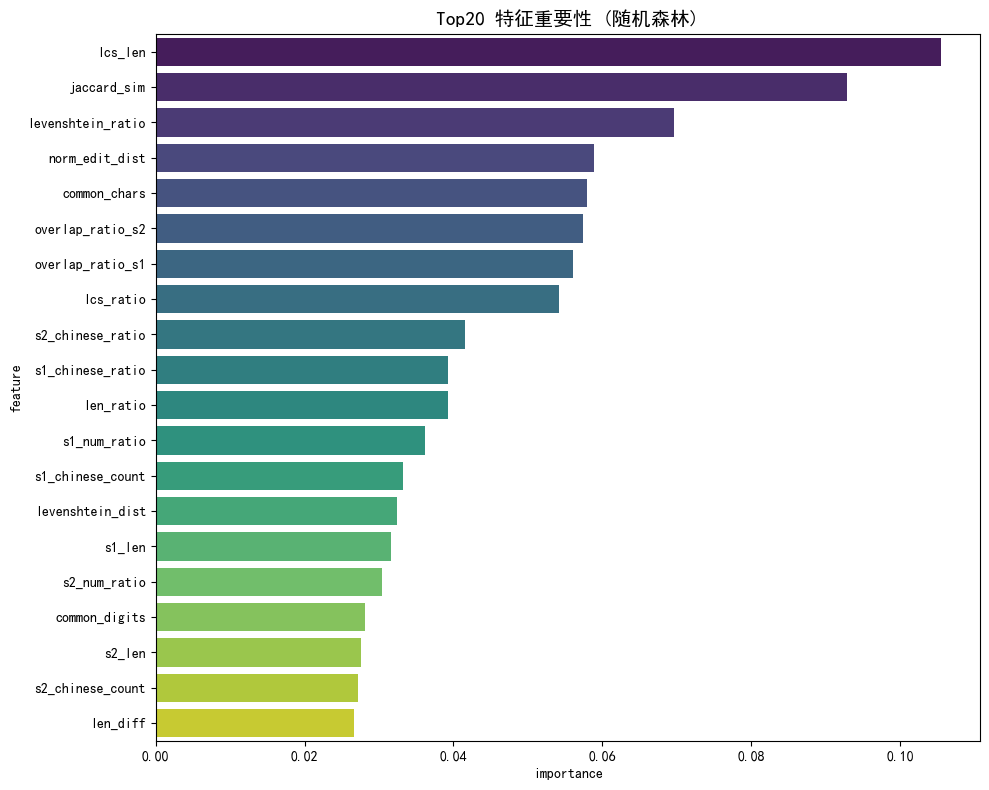


特征重要性排名:


,feature,importance
21,lcs_len,0.105486
13,jaccard_sim,0.092873
19,levenshtein_ratio,0.069691
20,norm_edit_dist,0.058885
16,common_chars,0.057972
15,overlap_ratio_s2,0.057441
14,overlap_ratio_s1,0.056113
22,lcs_ratio,0.054190
12,s2_chinese_ratio,0.041529
11,s1_chinese_ratio,0.039305


In [31]:
# ============ 10. 特征重要性分析（基于随机森林） ============
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# 使用特征训练随机森林查看特征重要性
X_train = train_features[feature_cols].fillna(0).values
y_train = train_features['label_id'].values
X_dev = dev_features[feature_cols].fillna(0).values
y_dev = dev_features['label_id'].values

print("训练随机森林进行特征重要性分析...")
rf = RandomForestClassifier(n_estimators=100, max_depth=15, random_state=42, 
                            n_jobs=-1, class_weight='balanced')
rf.fit(X_train, y_train)

# 预测
y_pred = rf.predict(X_dev)
f1_macro = f1_score(y_dev, y_pred, average='macro')
f1_weighted = f1_score(y_dev, y_pred, average='weighted')

print(f"\n随机森林验证集 F1 (macro): {f1_macro:.4f}")
print(f"随机森林验证集 F1 (weighted): {f1_weighted:.4f}")
print("\n分类报告:")
print(classification_report(y_dev, y_pred, target_names=['完全匹配', '部分匹配', '不匹配']))

# 特征重要性排序
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=feat_imp.head(20), x='importance', y='feature', ax=ax, palette='viridis')
ax.set_title('Top20 特征重要性 (随机森林)', fontsize=14)
plt.tight_layout()
plt.show()

print("\n特征重要性排名:")
display(feat_imp.head(20))

构建TF-IDF特征...
TF-IDF特征维度: 5000


计算TF-IDF相似度: 100%|██████████| 22974/22974 [00:22<00:00, 1028.80it/s]


TF-IDF相似度特征已添加并保存


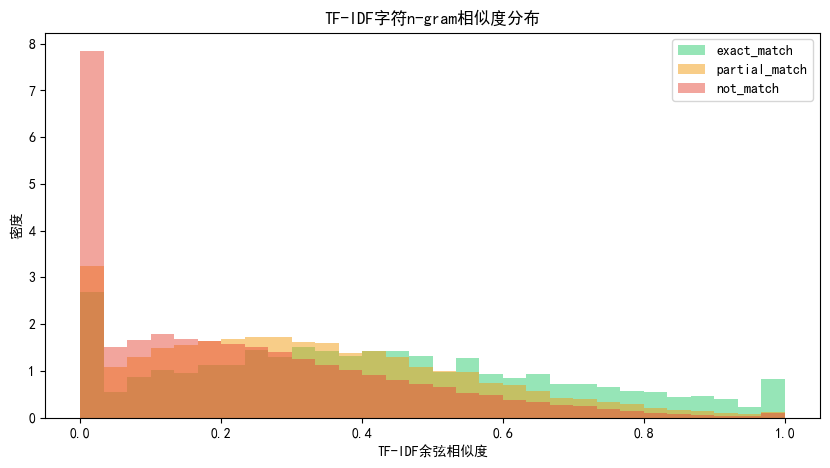


特征工程完成！共构建特征数: 24


: 

In [ ]:
# ============ 11. TF-IDF向量化特征 ============
print("构建TF-IDF特征...")

# 将两个句子拼接
train_texts = train_df['sentence1'] + ' ' + train_df['sentence2']
dev_texts = dev_df['sentence1'] + ' ' + dev_df['sentence2']

# TF-IDF向量化
tfidf = TfidfVectorizer(analyzer='char', ngram_range=(2, 4), max_features=5000, 
                        sublinear_tf=True)
train_tfidf = tfidf.fit_transform(train_texts)
dev_tfidf = tfidf.transform(dev_texts)

print(f"TF-IDF特征维度: {train_tfidf.shape[1]}")

# TF-IDF余弦相似度
tfidf_sim_train = []
for i in tqdm(range(len(train_df)), desc="计算TF-IDF相似度"):
    vec1 = tfidf.transform([train_df.iloc[i]['sentence1']])
    vec2 = tfidf.transform([train_df.iloc[i]['sentence2']])
    sim = cosine_similarity(vec1, vec2)[0][0]
    tfidf_sim_train.append(sim)

tfidf_sim_dev = []
for i in tqdm(range(len(dev_df)), desc="计算TF-IDF相似度"):
    vec1 = tfidf.transform([dev_df.iloc[i]['sentence1']])
    vec2 = tfidf.transform([dev_df.iloc[i]['sentence2']])
    sim = cosine_similarity(vec1, vec2)[0][0]
    tfidf_sim_dev.append(sim)

# 保存TF-IDF相似度特征
train_features['tfidf_sim'] = tfidf_sim_train
dev_features['tfidf_sim'] = tfidf_sim_dev

# 更新特征保存
train_features.to_csv(os.path.join(OUTPUT_DIR, 'train_features.csv'), index=False)
dev_features.to_csv(os.path.join(OUTPUT_DIR, 'dev_features.csv'), index=False)
print("TF-IDF相似度特征已添加并保存")

# 可视化TF-IDF相似度
fig, ax = plt.subplots(figsize=(10, 5))
for idx, label in enumerate(['exact_match', 'partial_match', 'not_match']):
    mask = train_df['label'] == label
    sims = [tfidf_sim_train[i] for i in range(len(train_df)) if train_df.iloc[i]['label'] == label]
    ax.hist(sims, alpha=0.5, label=label, color=colors_map[label], bins=30, density=True)
ax.set_xlabel('TF-IDF余弦相似度')
ax.set_ylabel('密度')
ax.set_title('TF-IDF字符n-gram相似度分布')
ax.legend()
plt.show()

print("\n特征工程完成！共构建特征数:", len(feature_cols) + 1)  # +1 for tfidf_sim